# EDA — Analyse géographique et lien avec l'orientation politique
## Municipales 2008–2020

**Objectif de ce notebook**

Le notebook précédent (`01_EDA_Municipales_Voix`) a traité l'hétérogénéité statistique
liée au panachage (communes < 1000 hab.) et produit un jeu de données nettoyé et
normalisé (`Analysis_Municipale.csv`), chargé ici via `load_and_clean_processed_analysis_municipal()`.

Ici, on cherche à savoir **s'il existe un lien entre la géographie et le vote** :

1. **Classification politique** : regrouper les `Code Nuance` (acronymes du Ministère
   de l'Intérieur, ex. `LUG`, `LDVD`, `LRN`...) en grands blocs gauche / centre / droite /
   extrêmes, pour pouvoir comparer des territoires entre eux.
2. **Lien démographique** : la taille de commune (population, strate < / >= 1000 hab.)
   est-elle associée à une orientation politique dominante différente ?
3. **Lien territorial** : existe-t-il des écarts d'orientation politique selon le
   département / la région ?
4. **Cartographie** : visualiser spatialement (longitude/latitude) l'orientation
   politique dominante par commune.

**Limite méthodologique à garder en tête** : le `Code Nuance` n'est disponible que pour
698 472 lignes sur 1 629 387 (≈ 43 %) — cf. `df.info()` du notebook. Les communes
< 1000 hab. (scrutin majoritaire avec panachage) ont une nuance attribuée à la liste de
manière plus irrégulière que les communes >= 1000 hab. (scrutin de liste proportionnel).
On gardera cette limite à l'esprit dans l'interprétation, en particulier pour le point 2.


In [58]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style="whitegrid")

from src.preprocessing import load_and_clean_processed_analysis_municipal

In [59]:
df = load_and_clean_processed_analysis_municipal()
print(df.shape)
df.head()

(1584251, 30)


,Annee,Tour,Code département,Code commune,Libellé commune,Code BV,Inscrits,Votants,Abstentions,Exprimés,Code Nuance,Voix,Nuance,Libellé,code_insee,geo_nom,population,surface_km2,longitude,latitude,ID Bureau de vote,Vote Blanc,strate,bureau_anormal,taux_participation,taux_abstention,taux_vote_blanc_nul,nb_sieges_estime,pct_voix_exprimes_brut,pct_voix_exprimes_normalise
0,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LUG,172.0,LUG,Liste Union de la Gauche,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.292020,0.292020
1,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LGC,111.0,LGC,Liste gauche-centristes,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.188455,0.188455
2,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LDVD,214.0,LDVD,Liste divers droite,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.363328,0.363328
3,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LDVD,92.0,LDVD,Liste divers droite,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.156197,0.156197
4,2008,1,1,4,Ambérieu-en-Bugey,0002,935,497,438,477,LUG,148.0,LUG,Liste Union de la Gauche,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,2,20,>= 1000 hab,False,0.531551,0.468449,0.040241,1.0,0.310273,0.310273


In [60]:
print("=== df (résultats détaillés) ===")
df.info()

=== df (résultats détaillés) ===
<class 'pandas.DataFrame'>
RangeIndex: 1584251 entries, 0 to 1584250
Data columns (total 30 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Annee                        1584251 non-null  int64  
 1   Tour                         1584251 non-null  int64  
 2   Code département             1584251 non-null  int64  
 3   Code commune                 1584251 non-null  int64  
 4   Libellé commune              1584251 non-null  str    
 5   Code BV                      1584251 non-null  str    
 6   Inscrits                     1584251 non-null  int64  
 7   Votants                      1584251 non-null  int64  
 8   Abstentions                  1584251 non-null  int64  
 9   Exprimés                     1584251 non-null  int64  
 10  Code Nuance                  1584251 non-null  str    
 11  Voix                         1584251 non-null  float64
 12  Nuance              

## 1. Classification politique : des `Code Nuance` aux grands blocs

Le Ministère de l'Intérieur attribue à chaque liste un **code de nuance** (circulaires
dites de « nuançage », revues à chaque élection — la dernière en date pour les
municipales 2026 distingue 6 blocs : `EXG`, `GAU`, `AUT`/`ECO`, `CENT`, `DTE`, `EXD`).
Le jeu de données couvrant 2008 à 2020, les codes rencontrés mélangent plusieurs
référentiels successifs (ex. `LUG`, `LGC` pour 2008-2014, puis des codes plus fins
ensuite). On construit donc un dictionnaire de correspondance **tolérant** :

- basé sur le **préfixe sémantique** du code (ex. tout ce qui contient `COM`, `FI`,
  `SOC`, `RDG`, `UG`, `VEC`, `DVG` → *Gauche*),
- avec un bloc `Extrême gauche` et `Extrême droite` séparés des blocs `Gauche`/`Droite`
  « classiques », car c'est une distinction qu'on voudra souvent réutiliser,
- une catégorie `Centre`, une catégorie `Écologiste` (les écologistes ne sont pas
  toujours classés à gauche par le Ministère — on les garde à part par défaut),
- une catégorie `Régionaliste / Divers` pour le reste,
- **à ajuster si vous avez une liste exhaustive et à jour des codes réellement présents
  dans votre `Code Nuance`** (cf. cellule suivante qui les affiche).

⚠️ Cette grille est une proposition de départ, pas une vérité absolue : le nuançage est
un exercice administratif, pas une mesure scientifique de l'idéologie d'une liste.


In [61]:
# Inventaire des codes de nuance réellement présents dans le jeu de données,
# avec leur fréquence -- à comparer à la grille de correspondance ci-dessous
# pour repérer d'éventuels codes non couverts ("Non classé").
print(f"Nombre de codes de nuance distincts : {df['Code Nuance'].nunique()}")
df['Code Nuance'].value_counts()


Nombre de codes de nuance distincts : 40


Code Nuance
NC      892418
LDVD    110662
LDVG     91904
LUG      72316
LEXG     57109
LDIV     49787
LDVC     35399
LUD      28036
LRN      25809
LSOC     25765
LFN      24110
LMAJ     22947
LNC      18057
LVEC     17302
LFI      15444
LLR      10769
LUMP      9990
LCMD      9860
LUC       9845
LFG       9074
LCOM      7016
LREM      6876
LUDI      5190
LMC       4532
LECO      4258
LUXD      4228
LEXD      4207
LAUT      2627
LGC       2418
LPG       1845
LMDM      1271
LREC      1234
LREG       503
LDLF       456
LUDR       378
LHOR       354
LRDG       116
LGJ         62
LDSV        40
LREN        37
Name: count, dtype: int64

In [62]:
# Grille de correspondance Code Nuance -> bloc politique
# Construite à partir de la liste exhaustive des nuances rencontrées dans le jeu de
# données (2008-2026), classées selon les blocs de clivage du Ministère de l'Intérieur.

NUANCE_TO_BLOC = {
    # --- Extrême gauche ---
    "EXG":  "Extrême gauche",
    "LEXG": "Extrême gauche",
    "DXG":  "Extrême gauche",

    # --- Gauche ---
    "COM":  "Gauche",
    "PG":   "Gauche",
    "SOC":  "Gauche",
    "RDG":  "Gauche",
    "DVG":  "Gauche",
    "LCOP": "Gauche",
    "LSOC": "Gauche",
    "LDVG": "Gauche",
    "LFG":  "Gauche",
    "LPG":  "Gauche",
    "LCOM": "Gauche",
    "LUG":  "Gauche",
    "LRDG": "Gauche",
    "FG":   "Gauche",
    "FI":   "Gauche",
    "LFI":  "Gauche",
    "NUP":  "Gauche",
    "LGC":  "Gauche",   # gauche-centriste (2008)
    "LUCG": "Gauche",   # union au centre et à gauche -> rattaché gauche
    "LUGE": "Gauche",   # union à gauche avec écologistes
    "LVEG": "Gauche",   # EELV et gauche

    # --- Écologistes (catégorie à part) ---
    "VEC":  "Écologiste",
    "ECO":  "Écologiste",
    "LVEC": "Écologiste",
    "LECO": "Écologiste",

    # --- Centre ---
    "MODM": "Centre",
    "M-NC": "Centre",
    "M":    "Centre",
    "UDFD": "Centre",
    "MAJ":  "Centre",
    "CEN":  "Centre",
    "ALLI": "Centre",
    "PRV":  "Centre",
    "NCE":  "Centre",
    "REM":  "Centre",
    "MDM":  "Centre",
    "UDI":  "Centre",
    "ENS":  "Centre",
    "DVC":  "Centre",
    "LCMD": "Centre",
    "LMAJ": "Centre",
    "LMDM": "Centre",
    "LUC":  "Centre",
    "LUDI": "Centre",
    "LREM": "Centre",
    "LDVC": "Centre",
    "LMC":  "Centre",
    "LHOR":  "Centre",
    "LMMD": "Centre",
    "LCEN": "Centre",
    "LUCD": "Centre",   # union au centre et à droite -> rattaché centre
    "LMP":  "Centre",   # majorité présidentielle

    # --- Droite ---
    "UMP":  "Droite",
    "DVD":  "Droite",
    "MPF":  "Droite",
    "LR":   "Droite",
    "DLF":  "Droite",
    "DSV":  "Droite",
    "REC":  "Droite",
    "LDVD": "Droite",
    "LUMP": "Droite",
    "LUD":  "Droite",
    "LUDR":  "Droite",
    "LLR":  "Droite",
    "LDLF": "Droite",
    "DLR":  "Droite",
    "LDLR": "Droite",

    # --- Extrême droite ---
    "FN":   "Extrême droite",
    "EXD":  "Extrême droite",
    "LFN":  "Extrême droite",
    "LEXD": "Extrême droite",
    "LDSV": "Extrême droite",  # souverainiste de droite -> classé extrême droite
    "RN":   "Extrême droite",
    "LRN":  "Extrême droite",
    "LREN":  "Extrême droite",
    "DXD":  "Extrême droite",
    "LUXD": "Extrême droite",
    "LREC": "Extrême droite",

    # --- Régionalistes / divers / sans étiquette ---
    "REG":  "Régionaliste / Divers",
    "AUT":  "Régionaliste / Divers",
    "LREG": "Régionaliste / Divers",
    "LAUT": "Régionaliste / Divers",
    "LDIV": "Régionaliste / Divers",
    "DIV":  "Régionaliste / Divers",
    "CPNT": "Régionaliste / Divers",
    "LGJ":  "Régionaliste / Divers",
    "LNC":  "Non Communiqué",  # "Non Communiqué"
    "NC":  "Non Communiqué",  # "Non Communiqué"
}

def code_to_bloc(code_nuance: str) -> str:
    """Associe un Code Nuance à un bloc politique (correspondance exacte
    uniquement, la grille ci-dessus couvrant l'intégralité des codes connus)."""
    if pd.isna(code_nuance):
        return "Non renseigné"
    code_nuance = str(code_nuance).strip().upper()
    return NUANCE_TO_BLOC.get(code_nuance, "Non classé")

df["bloc_politique"] = df["Code Nuance"].apply(code_to_bloc)

repartition = df["bloc_politique"].value_counts(dropna=False)
repartition_pct = (repartition / len(df) * 100).round(2)
pd.DataFrame({"n_lignes": repartition, "pct": repartition_pct})

,n_lignes,pct
bloc_politique,,
Non Communiqué,910475,57.47
Gauche,225898,14.26
Droite,160291,10.12
Centre,96274,6.08
Extrême droite,59665,3.77
Extrême gauche,57109,3.60
Régionaliste / Divers,52979,3.34
Écologiste,21560,1.36


In [63]:
# Zoom sur les codes tombés dans "Non classé" : à examiner pour enrichir la grille
non_classes = df.loc[df["bloc_politique"] == "Non classé", "Code Nuance"].value_counts()
print(f"{len(non_classes)} code(s) de nuance non couverts par la grille :")
non_classes


0 code(s) de nuance non couverts par la grille :


Series([], Name: count, dtype: int64)

## 2. Construction d'un indicateur d'orientation politique par commune

Pour relier géographie et politique, on a besoin d'un indicateur **par commune et par
élection** (et non par ligne candidat/nuance). On définit :

- `voix_bloc` : somme des `Voix` par commune × année × tour × bloc politique,
- `bloc_majoritaire` : le bloc politique ayant recueilli le plus de voix dans la commune
  pour cette élection (en utilisant `pct_voix_exprimes_normalise`, qui corrige déjà
  l'effet panachage vu dans le notebook 1, plutôt que les voix brutes),
- on travaille uniquement sur le **2nd tour** quand il existe (résultat le plus proche
  du résultat final), sinon le 1er tour (cas des listes élues dès le 1er tour).

On exclut les lignes `bloc_politique` égal à `"Non renseigné"` ou `"Non classé"` du
calcul du score, mais on les garde dans le dénominateur via `Exprimés` pour ne pas
fausser les taux de participation calculés ailleurs.


In [64]:
# On privilégie le tour le plus "décisif" disponible par commune/année :
# le 2nd tour s'il existe, sinon le 1er tour (élection dès le 1er tour).
tour_max = (
    df.groupby(["Annee", "Code département", "Code commune"])["Tour"]
    .max()
    .reset_index()
    .rename(columns={"Tour": "Tour_retenu"})
)

df_tour = df.merge(tour_max, on=["Annee", "Code département", "Code commune"], how="left")
df_tour = df_tour[df_tour["Tour"] == df_tour["Tour_retenu"]].copy()

print(f"Lignes après sélection du tour décisif : {len(df_tour)} (sur {len(df)})")


Lignes après sélection du tour décisif : 1090590 (sur 1584251)


In [65]:
# Score politique par commune x année : somme des voix normalisées par bloc
mask_classe = ~df_tour["bloc_politique"].isin(["Non renseigné", "Non classé", "Non Communiqué"])

score_bloc = (
    df_tour[mask_classe]
    .groupby(["Annee", "Code département", "Code commune", "code_insee", "geo_nom",
              "population", "strate", "longitude", "latitude", "bloc_politique"])
    ["pct_voix_exprimes_normalise"]
    .sum()
    .reset_index()
)

# Bloc majoritaire = celui avec le score le plus élevé, par commune x année
idx_max = (
    score_bloc.groupby(["Annee", "Code département", "Code commune"])
    ["pct_voix_exprimes_normalise"]
    .idxmax()
)
commune_bloc = score_bloc.loc[idx_max].reset_index(drop=True)
commune_bloc = commune_bloc.rename(columns={
    "pct_voix_exprimes_normalise": "score_bloc_majoritaire",
    "bloc_politique": "bloc_majoritaire",
})

print(f"Nombre de communes x années avec un bloc majoritaire identifié : {len(commune_bloc)}")
commune_bloc.head()


Nombre de communes x années avec un bloc majoritaire identifié : 14733


,Annee,Code département,Code commune,code_insee,geo_nom,population,strate,longitude,latitude,bloc_majoritaire,score_bloc_majoritaire
0,2008,1,4,1004,Ambérieu-en-Bugey,15934.0,>= 1000 hab,5.3706,45.9575,Gauche,4.291204
1,2008,1,14,1014,Arbent,3555.0,>= 1000 hab,5.6879,46.2838,Centre,1.584159
2,2008,1,33,1033,Valserhône,16712.0,>= 1000 hab,5.7944,46.1234,Centre,4.069253
3,2008,1,34,1034,Belley,9388.0,>= 1000 hab,5.6927,45.7430,Gauche,2.564981
4,2008,1,43,1043,Beynost,5198.0,>= 1000 hab,4.9964,45.8359,Droite,3.000000


### 2.1 Aller au-delà du "qui gagne" : le score de voix de chaque bloc

`commune_bloc` ne retient que le bloc **majoritaire** par commune. Pour analyser un
vrai **lien avec les voix** (et pas seulement un lien avec la victoire), on a besoin
du score complet de **chaque bloc** dans **chaque commune**, sous forme large
(`score_bloc` déjà calculé ci-dessus, qu'on pivote ici). On y ajoute aussi
`taux_participation` et `taux_abstention` au niveau commune, pour pouvoir croiser
participation et orientation politique plus loin.


In [66]:
# Table large : une colonne de score par bloc politique, une ligne par commune x année
scores_wide = score_bloc.pivot_table(
    index=["Annee", "Code département", "Code commune", "code_insee", "geo_nom",
           "population", "strate", "longitude", "latitude"],
    columns="bloc_politique",
    values="pct_voix_exprimes_normalise",
    fill_value=0,
).reset_index()
scores_wide.columns.name = None

# Participation / abstention au niveau commune (moyenne pondérée par les Inscrits
# des bureaux de vote, pour ne pas donner le même poids à un petit et un gros bureau)
def moyenne_ponderee(g, col, poids="Inscrits"):
    return np.average(g[col], weights=g[poids]) if g[poids].sum() > 0 else np.nan

participation_commune = (
    df_tour.drop_duplicates(["Annee", "Code département", "Code commune", "Code BV"])
    .groupby(["Annee", "Code département", "Code commune"])
    .apply(lambda g: pd.Series({
        "taux_participation": moyenne_ponderee(g, "taux_participation"),
        "taux_abstention": moyenne_ponderee(g, "taux_abstention"),
    }))
    .reset_index()
)

scores_wide = scores_wide.merge(
    participation_commune, on=["Annee", "Code département", "Code commune"], how="left"
)

blocs_cols = [c for c in scores_wide.columns if c in score_bloc["bloc_politique"].unique()]
print(f"Blocs disponibles en colonnes : {blocs_cols}")
scores_wide.head()


Blocs disponibles en colonnes : ['Centre', 'Droite', 'Extrême droite', 'Extrême gauche', 'Gauche', 'Régionaliste / Divers', 'Écologiste']


,Annee,Code département,Code commune,code_insee,geo_nom,population,strate,longitude,latitude,Centre,Droite,Extrême droite,Extrême gauche,Gauche,Régionaliste / Divers,Écologiste,taux_participation,taux_abstention
0,2008,1,4,1004,Ambérieu-en-Bugey,15934.0,>= 1000 hab,5.3706,45.9575,0.000000,3.708796,0.0,0.0,4.291204,0.0,0.0,0.570591,0.429409
1,2008,1,14,1014,Arbent,3555.0,>= 1000 hab,5.6879,46.2838,1.584159,0.415841,0.0,0.0,0.000000,0.0,0.0,0.644737,0.355263
2,2008,1,33,1033,Valserhône,16712.0,>= 1000 hab,5.7944,46.1234,4.069253,0.000000,0.0,0.0,2.930747,0.0,0.0,0.631964,0.368036
3,2008,1,34,1034,Belley,9388.0,>= 1000 hab,5.6927,45.7430,2.435019,0.000000,0.0,0.0,2.564981,0.0,0.0,0.713602,0.286398
4,2008,1,43,1043,Beynost,5198.0,>= 1000 hab,4.9964,45.8359,0.000000,3.000000,0.0,0.0,0.000000,0.0,0.0,0.633721,0.366279


In [67]:
scores_wide[scores_wide['Extrême gauche']> 0]

,Annee,Code département,Code commune,code_insee,geo_nom,population,strate,longitude,latitude,Centre,Droite,Extrême droite,Extrême gauche,Gauche,Régionaliste / Divers,Écologiste,taux_participation,taux_abstention
5,2008,1,53,1053,Bourg-en-Bresse,42372.0,>= 1000 hab,5.2469,46.2027,7.731167,0.000000,0.000000,0.674751,10.594082,0.000000,0.0,0.583770,0.416230
38,2008,2,408,2408,Laon,24220.0,>= 1000 hab,3.6130,49.5711,10.293753,0.896637,0.000000,0.798600,6.215407,0.795603,0.0,0.584875,0.415125
51,2008,3,185,3185,Montluçon,33147.0,>= 1000 hab,2.6080,46.3428,13.372605,0.000000,0.000000,1.190783,12.436611,0.000000,0.0,0.666376,0.333624
74,2008,6,88,6088,Nice,357737.0,>= 1000 hab,7.2528,43.7032,91.845601,54.413882,17.029436,4.695295,68.015787,0.000000,0.0,0.582540,0.417460
143,2008,13,2,13002,Allauch,21443.0,>= 1000 hab,5.5103,43.3522,0.000000,0.000000,0.000000,3.249350,13.750650,0.000000,0.0,0.657027,0.342973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14637,2020,94,33,94033,Fontenay-sous-Bois,53757.0,>= 1000 hab,2.4736,48.8503,3.535803,9.881463,0.000000,0.579258,19.003476,0.000000,0.0,0.384995,0.615005
14645,2020,94,46,94046,Maisons-Alfort,56799.0,>= 1000 hab,2.4400,48.8017,2.113853,27.328537,0.000000,1.385871,6.171739,0.000000,0.0,0.399862,0.600138
14661,2020,94,73,94073,Thiais,32918.0,>= 1000 hab,2.3869,48.7605,1.957577,7.913503,0.000000,0.369142,2.759778,0.000000,0.0,0.347813,0.652187
14689,2020,95,219,95219,Ermont,29489.0,>= 1000 hab,2.2580,48.9891,0.000000,13.505694,0.000000,0.896135,5.598171,0.000000,0.0,0.328430,0.671570


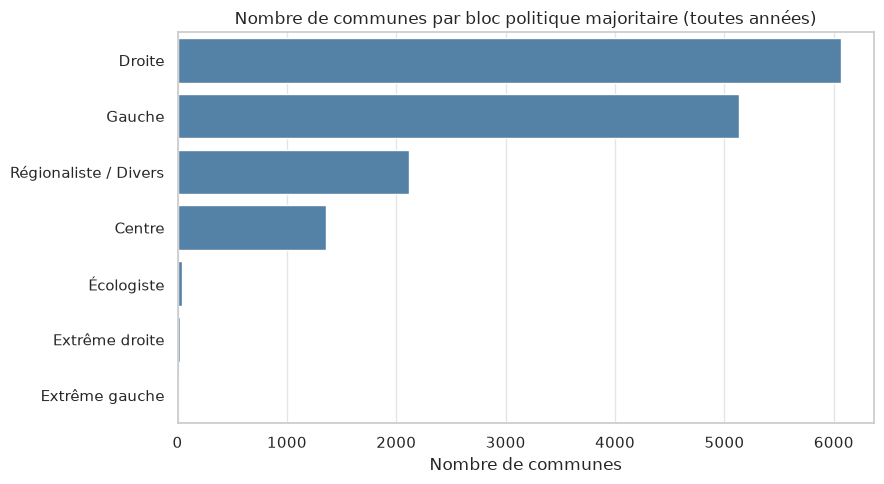

In [68]:
# Répartition des communes par bloc majoritaire, toutes années confondues
fig, ax = plt.subplots(figsize=(9, 5))
ordre = commune_bloc["bloc_majoritaire"].value_counts().index
sns.countplot(data=commune_bloc, y="bloc_majoritaire", order=ordre, ax=ax, color="steelblue")
ax.set_title("Nombre de communes par bloc politique majoritaire (toutes années)")
ax.set_xlabel("Nombre de communes")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


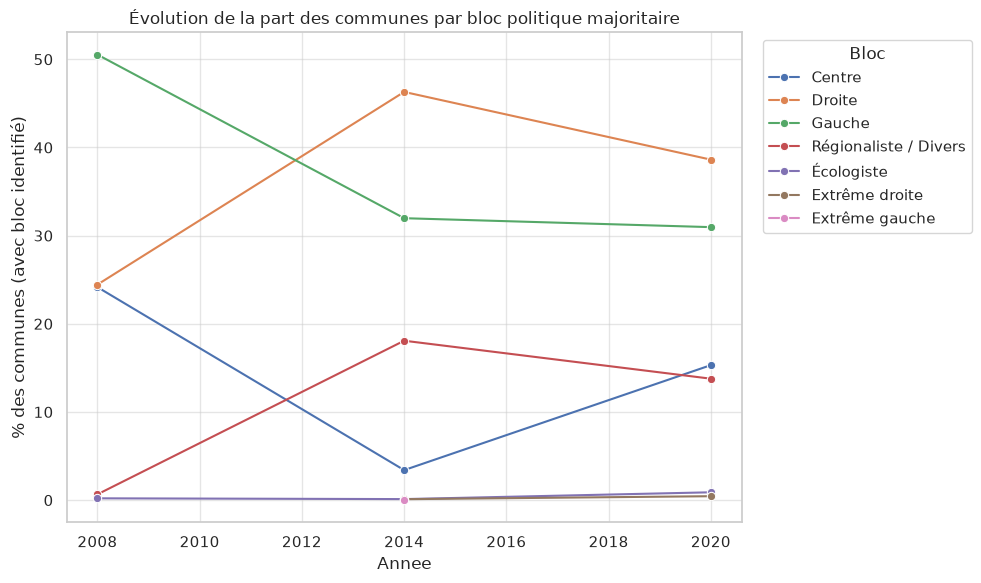

In [69]:
# Évolution du bloc majoritaire dans le temps (en % des communes couvertes chaque année)
counts = commune_bloc.groupby(["Annee", "bloc_majoritaire"]).size().rename("n")
totals = commune_bloc.groupby("Annee").size().rename("total")

evolution = (
    counts
    .reset_index()
    .merge(totals.reset_index(), on="Annee")
    .assign(pct_communes=lambda d: 100 * d["n"] / d["total"])
    .drop(columns=["n", "total"])
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=evolution, x="Annee", y="pct_communes", hue="bloc_majoritaire", marker="o", ax=ax)
ax.set_title("Évolution de la part des communes par bloc politique majoritaire")
ax.set_ylabel("% des communes (avec bloc identifié)")
ax.legend(title="Bloc", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 3. Lien entre taille de commune et orientation politique

On regarde si la **strate de population** (`< 1000 hab.` / `>= 1000 hab.`, telle que
définie dans le notebook 1) est associée à une orientation politique différente.

⚠️ Rappel de la limite méthodologique : les communes < 1000 hab. ont un régime de
scrutin différent (panachage), et le nuançage y est historiquement plus rare /
moins homogène que pour les listes des communes >= 1000 hab. Une partie de l'écart
observé pourra donc être un **biais de couverture du nuançage** plutôt qu'un vrai
effet politique — à garder en tête dans la lecture des graphiques ci-dessous.


In [70]:
# Taux de couverture du nuançage par strate (pour objectiver le biais évoqué)
couverture = (
    df.groupby("strate")["bloc_politique"]
    .apply(lambda s: 100 * (~s.isin(["Non renseigné", "Non classé", "Non Communiqué"])).mean())
    .rename("pct_lignes_classees")
)
print(couverture.round(1))


strate
< 1000 hab     10.1
>= 1000 hab    92.6
Name: pct_lignes_classees, dtype: float64


In [71]:
# Répartition du bloc majoritaire par strate de population
tab_strate = pd.crosstab(commune_bloc["strate"], commune_bloc["bloc_majoritaire"], normalize="index") * 100
tab_strate = tab_strate.round(1)
tab_strate

bloc_majoritaire,Centre,Droite,Extrême droite,Extrême gauche,Gauche,Régionaliste / Divers,Écologiste
strate,,,,,,,
< 1000 hab,3.0,37.3,0.0,0.0,30.7,28.9,0.0
>= 1000 hab,9.3,41.2,0.2,0.0,34.9,14.2,0.3


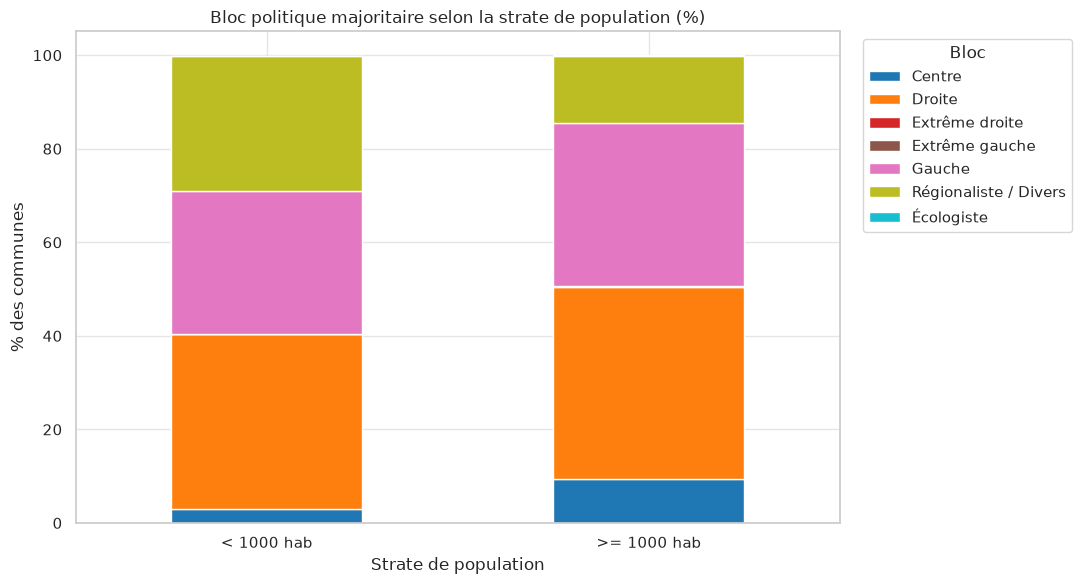

In [72]:
fig, ax = plt.subplots(figsize=(11, 6))
tab_strate.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Bloc politique majoritaire selon la strate de population (%)")
ax.set_ylabel("% des communes")
ax.set_xlabel("Strate de population")
ax.legend(title="Bloc", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


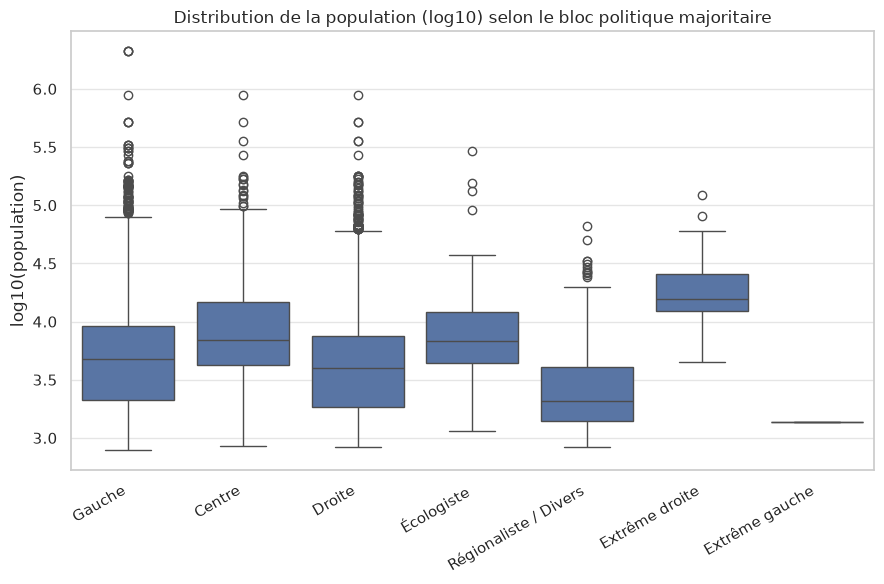

In [73]:
# Vision continue : population (log) vs score du bloc majoritaire
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = commune_bloc.copy()
plot_data["population_log"] = np.log10(plot_data["population"].clip(lower=1))
sns.boxplot(data=plot_data, x="bloc_majoritaire", y="population_log", ax=ax)
ax.set_title("Distribution de la population (log10) selon le bloc politique majoritaire")
ax.set_ylabel("log10(population)")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 3.1 Corrélation entre population et score de voix de chaque bloc

Au-delà de "qui gagne", on regarde si le **score continu** de chaque bloc (part des
voix, normalisée du panachage) évolue avec la taille de la commune — une corrélation
significative est un lien plus fin et plus robuste qu'une comparaison de blocs
majoritaires (qui peut être dominée par des effets de seuil proches de 50 %).


In [74]:
# Corrélation de Spearman (relation monotone, pas forcément linéaire) entre
# population (log) et score de chaque bloc politique
scores_wide["population_log"] = np.log10(scores_wide["population"].clip(lower=1))

from scipy.stats import spearmanr

correlations = []
for bloc in blocs_cols:
    valid = scores_wide[["population_log", bloc]].dropna()
    if len(valid) < 30:
        continue
    rho, p = spearmanr(valid["population_log"], valid[bloc])
    correlations.append({"bloc": bloc, "rho_spearman": rho, "p_value": p, "n": len(valid)})

corr_df = pd.DataFrame(correlations).sort_values("rho_spearman")
corr_df


,bloc,rho_spearman,p_value,n
5,Régionaliste / Divers,-0.138895,2.291471e-64,14733
6,Écologiste,0.164878,2.738102e-90,14733
3,Extrême gauche,0.199163,1.122894e-131,14733
2,Extrême droite,0.276293,2.307648e-256,14733
1,Droite,0.343439,0.000000e+00,14733
0,Centre,0.377161,0.000000e+00,14733
4,Gauche,0.590065,0.000000e+00,14733


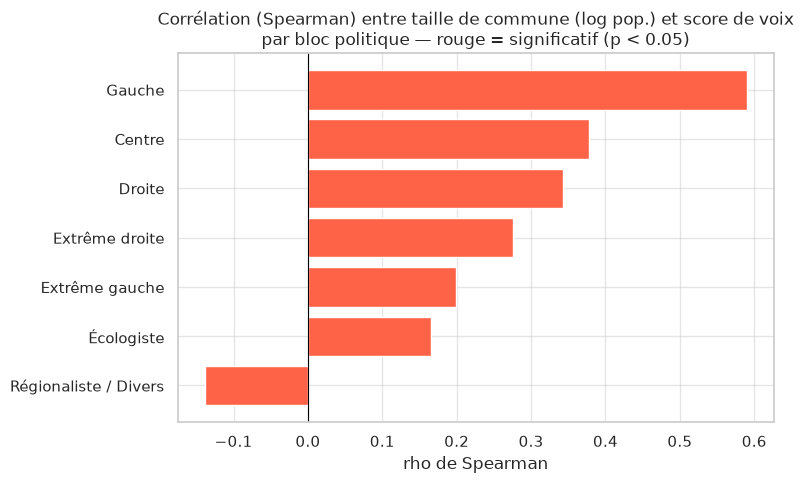

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tomato" if p < 0.05 else "lightgray" for p in corr_df["p_value"]]
ax.barh(corr_df["bloc"], corr_df["rho_spearman"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Corrélation (Spearman) entre taille de commune (log pop.) et score de voix\npar bloc politique — rouge = significatif (p < 0.05)")
ax.set_xlabel("rho de Spearman")
plt.tight_layout()
plt.show()


### 3.2 Participation / abstention selon la strate et le bloc majoritaire

On regarde si le **taux de participation** (qui dépend lui aussi des voix, via
`Votants`/`Inscrits`) varie selon la strate de population, et si cette variation
diffère selon le bloc politique majoritaire de la commune — un croisement à trois
variables qui peut révéler des effets que les analyses séparées masquent.


In [76]:
# Participation moyenne par strate x bloc majoritaire
part_strate_bloc = (
    commune_bloc.merge(
        scores_wide[["Annee", "Code département", "Code commune", "taux_participation", "taux_abstention"]],
        on=["Annee", "Code département", "Code commune"], how="left",
    )
)

tab_participation = (
    part_strate_bloc.groupby(["strate", "bloc_majoritaire"])["taux_participation"]
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)
tab_participation


bloc_majoritaire,Centre,Droite,Extrême droite,Extrême gauche,Gauche,Régionaliste / Divers,Écologiste
strate,,,,,,,
< 1000 hab,73.2,69.5,NaN,NaN,75.1,70.9,NaN
>= 1000 hab,57.5,61.8,56.0,63.9,62.1,64.0,53.5


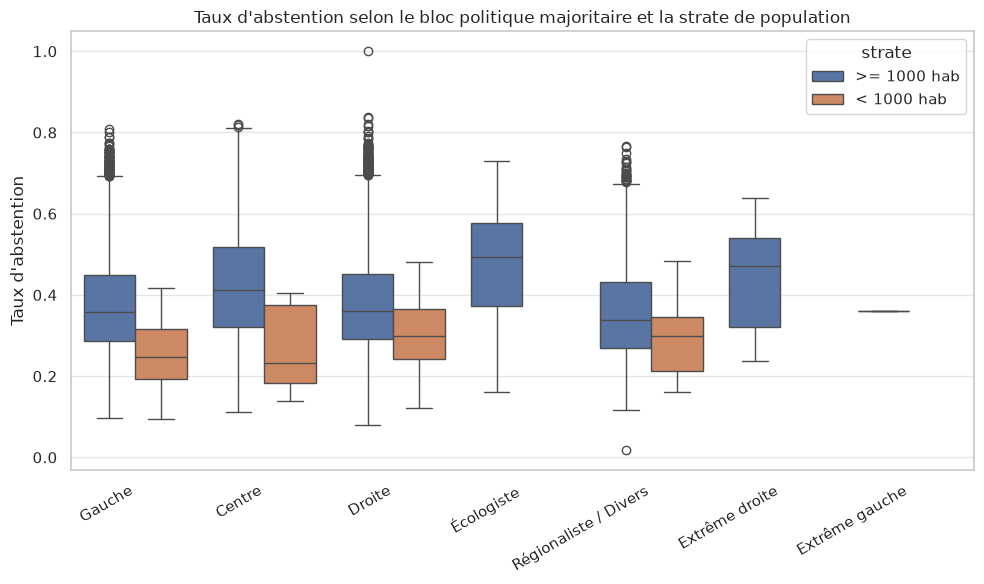

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=part_strate_bloc, x="bloc_majoritaire", y="taux_abstention", hue="strate", ax=ax)
ax.set_title("Taux d'abstention selon le bloc politique majoritaire et la strate de population")
ax.set_ylabel("Taux d'abstention")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Lien entre territoire (département) et orientation politique

`Code département` est disponible nativement. On calcule, pour chaque département,
la part de communes par bloc politique majoritaire, ce qui permet de repérer des
zones plus marquées à gauche / droite / centre.

(Si une colonne région existe dans vos données enrichies par l'API geo.gouv.fr —
`codeRegion`, vue dans le notebook 1 lors de l'appel à l'API — vous pouvez répéter
l'agrégation au niveau région de la même façon ; elle n'apparaît pas dans le `df.info()`
de ce notebook donc on reste ici au niveau département, qui est garanti présent.)


In [78]:
dept_bloc = (
    commune_bloc[commune_bloc["bloc_majoritaire"] != "Non Communiqué"].groupby("Code département")["bloc_majoritaire"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)

# Bloc dominant par département (celui avec le plus haut pourcentage de communes)
dept_dominant = (
    dept_bloc.sort_values("pct", ascending=False)
    .groupby("Code département")
    .first()
    .reset_index()
    .rename(columns={"bloc_majoritaire": "bloc_dominant_dept", "pct": "pct_dominant"})
)

print(f"Nombre de départements couverts : {dept_dominant['Code département'].nunique()}")
dept_dominant.sort_values("pct_dominant", ascending=False)


Nombre de départements couverts : 94


,Code département,bloc_dominant_dept,pct_dominant
73,75,Gauche,100.000000
83,85,Droite,79.385965
51,53,Droite,78.651685
65,67,Droite,76.491228
72,74,Droite,76.190476
...,...,...,...
78,80,Régionaliste / Divers,36.585366
28,30,Gauche,34.403670
88,90,Gauche,34.146341
33,35,Gauche,33.431953


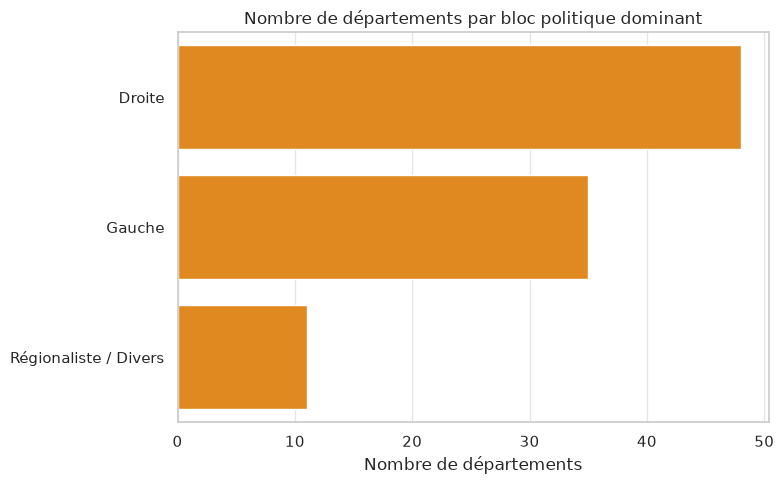

In [79]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=dept_dominant, y="bloc_dominant_dept",
              order=dept_dominant["bloc_dominant_dept"].value_counts().index,
              ax=ax, color="darkorange")
ax.set_title("Nombre de départements par bloc politique dominant")
ax.set_xlabel("Nombre de départements")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [80]:
# Top 10 départements les plus marqués (pct_dominant le plus élevé) pour chaque grand bloc
for bloc in ["Gauche", "Droite", "Centre", "Extrême droite", "Extrême gauche", "Écologiste"]:
    sous = dept_dominant[dept_dominant["bloc_dominant_dept"] == bloc].sort_values(
        "pct_dominant", ascending=False
    )
    if sous.empty:
        continue
    print(f"\n=== {bloc} : départements les plus homogènes ===")
    print(sous[["Code département", "pct_dominant"]].head(5).to_string(index=False))



=== Gauche : départements les plus homogènes ===
 Code département  pct_dominant
               75    100.000000
               87     75.757576
               31     75.451264
               23     73.076923
               62     66.958425

=== Droite : départements les plus homogènes ===
 Code département  pct_dominant
               85     79.385965
               53     78.651685
               67     76.491228
               74     76.190476
               52     70.588235


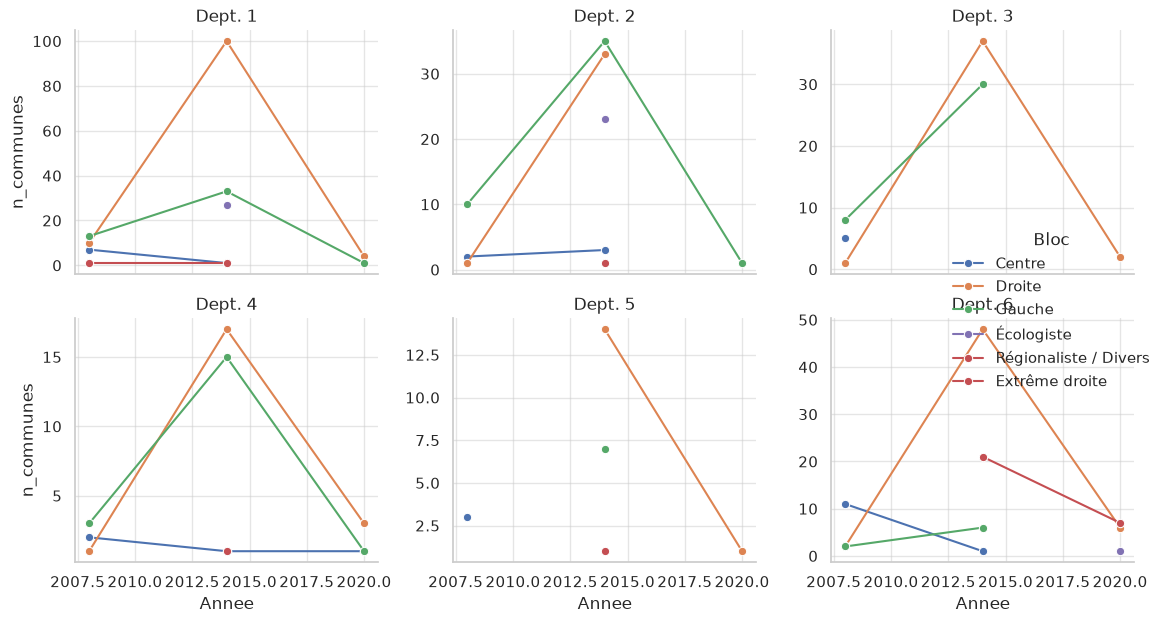

In [81]:
# Évolution dans le temps du bloc majoritaire pour quelques départements (exemple)
# -> à adapter avec les départements qui vous intéressent
depts_exemple = dept_dominant["Code département"].head(6).tolist()

evol_dept = (
    commune_bloc[commune_bloc["Code département"].isin(depts_exemple)]
    .groupby(["Annee", "Code département", "bloc_majoritaire"])
    .size()
    .reset_index(name="n_communes")
)

g = sns.FacetGrid(evol_dept, col="Code département", col_wrap=3, height=3.2, sharey=False)
g.map_dataframe(sns.lineplot, x="Annee", y="n_communes", hue="bloc_majoritaire", marker="o")
g.add_legend(title="Bloc")
g.set_titles("Dept. {col_name}")
plt.tight_layout()
plt.show()


### 4.1 Score moyen de voix par bloc, par département

Le bloc "dominant" (§4 ci-dessus) ne dit pas à quel point un département est marqué.
On calcule ici le **score moyen de voix** de chaque bloc par département — une mesure
continue, plus fine qu'un simple classement par victoire.


In [82]:
score_moyen_dept = (
    scores_wide.groupby("Code département")[blocs_cols]
    .mean()
    .mul(100)
    .round(1)
)
score_moyen_dept.sort_values("Gauche", ascending=False).head(10)


,Centre,Droite,Extrême droite,Extrême gauche,Gauche,Régionaliste / Divers,Écologiste
Code département,,,,,,,
75,12208.1,8645306.6,0.0,0.0,10441002.0,0.0,0.0
13,230.8,30027.1,17791.0,1.7,23406.7,75.2,10.3
69,211.6,9143.7,2848.3,3.2,13749.3,140.0,303.7
31,106.6,12538.3,22.0,1.6,12380.1,82.4,17.5
6,193.9,36177.4,14099.5,4.5,11608.8,7583.7,49.9
93,684.6,6899.8,184.9,83.0,11074.1,52.2,167.3
92,1276.5,21187.8,505.1,225.8,10797.6,1245.2,496.2
44,454.5,6626.8,96.8,49.3,8926.2,103.6,46.2
94,340.1,7842.2,786.5,42.4,7154.6,20.6,137.0


### 4.2 Participation / abstention par département

On regarde si l'abstention varie géographiquement, et si les départements les plus
abstentionnistes sont aussi ceux où un bloc particulier domine — un lien possible
entre désengagement électoral et orientation politique du territoire.


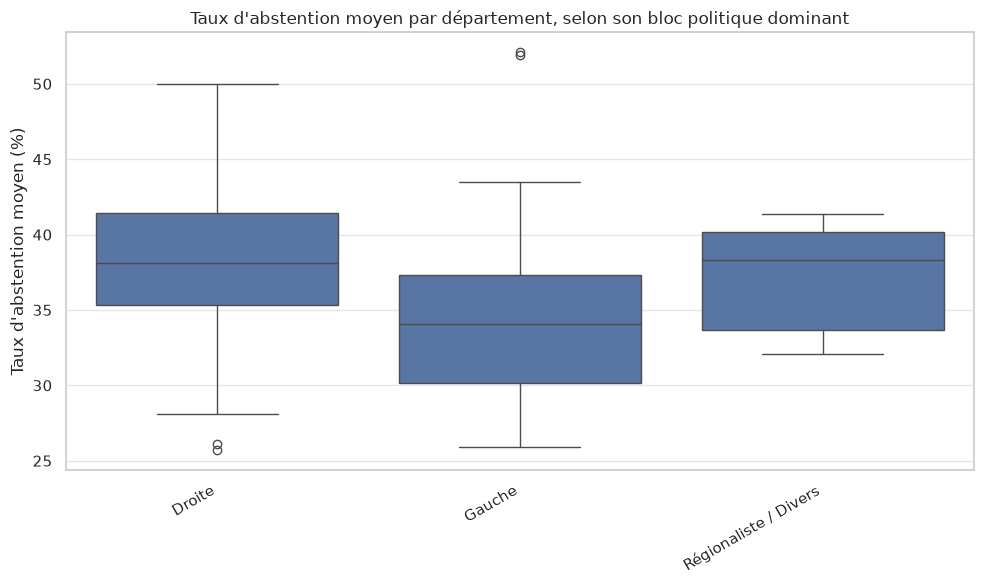

,taux_participation,taux_abstention,bloc_dominant_dept
Code département,,,
93,47.9,52.1,Gauche
75,48.1,51.9,Gauche
94,50.0,50.0,Droite
92,51.7,48.3,Droite
95,52.6,47.4,Droite
78,54.7,45.3,Droite
69,55.3,44.7,Droite
51,55.6,44.4,Droite
77,55.6,44.4,Droite


In [83]:
participation_dept = (
    scores_wide.groupby("Code département")[["taux_participation", "taux_abstention"]]
    .mean()
    .mul(100)
    .round(1)
    .merge(dept_dominant.set_index("Code département")[["bloc_dominant_dept"]],
           left_index=True, right_index=True, how="left")
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=participation_dept.reset_index(), x="bloc_dominant_dept", y="taux_abstention", ax=ax)
ax.set_title("Taux d'abstention moyen par département, selon son bloc politique dominant")
ax.set_ylabel("Taux d'abstention moyen (%)")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

participation_dept.sort_values("taux_abstention", ascending=False).head(10)


## 5. Cartographie : visualiser l'orientation politique dans l'espace

On utilise `longitude` / `latitude` (déjà présentes dans `df`, récupérées via l'API
geo.gouv.fr dans le notebook 1) pour un scatter géographique simple, coloré par bloc
politique majoritaire. Ce n'est pas une vraie carte avec fond de carte (pas de
dépendance géo lourde type `geopandas`/`folium` ici), mais la forme du nuage de points
reproduit déjà la silhouette de la France métropolitaine et suffit à un premier
diagnostic visuel.

Pour aller plus loin (fond de carte, projections, export interactif), `geopandas` +
un shapefile des communes ou `folium` seraient l'étape naturelle suivante si besoin.


Communes x années avec coordonnées disponibles : 14733 / 14733


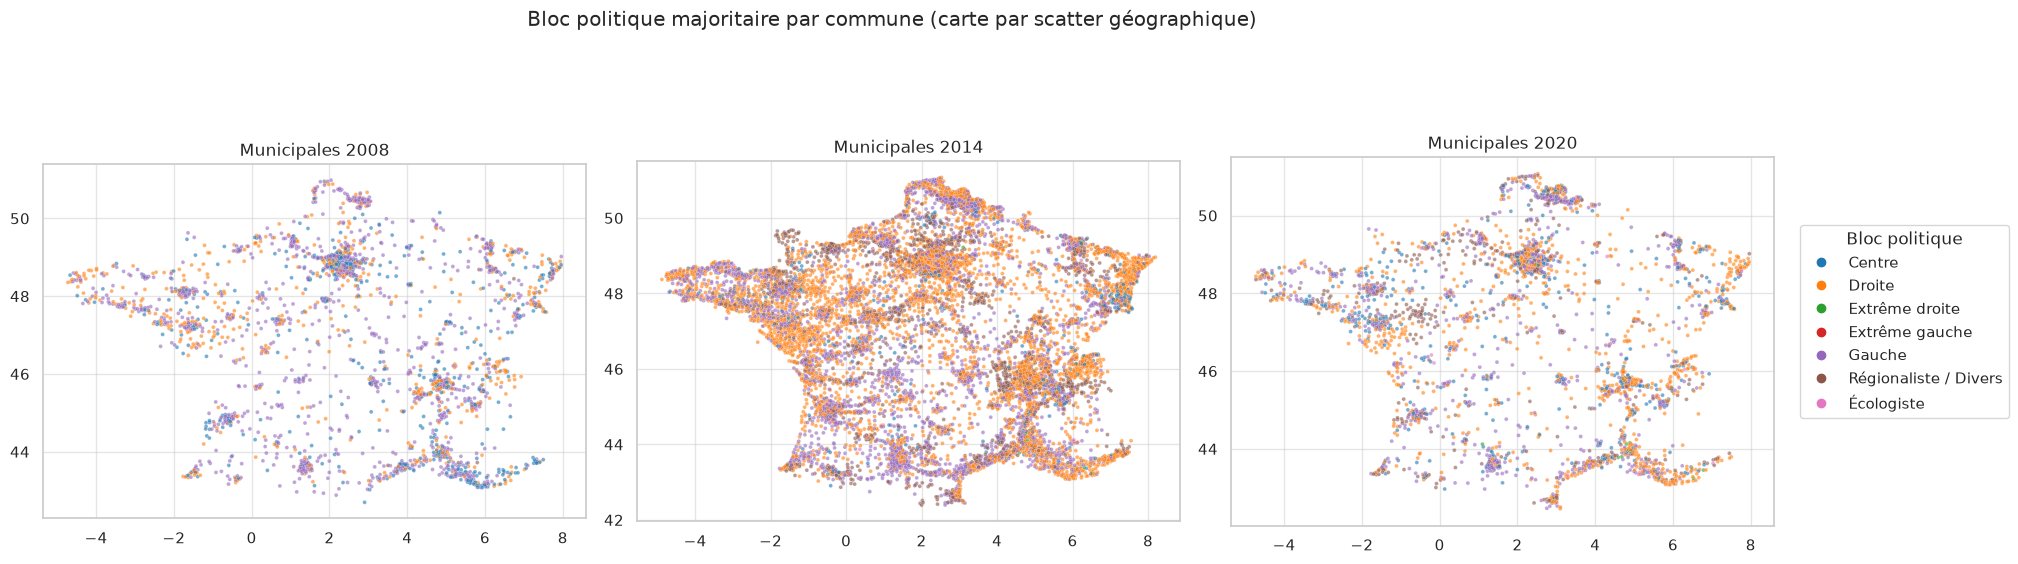

In [84]:
# Une carte par année (facettes), pour voir l'évolution spatiale du vote
geo_plot = commune_bloc.dropna(subset=["longitude", "latitude"]).copy()
print(f"Communes x années avec coordonnées disponibles : {len(geo_plot)} / {len(commune_bloc)}")

annees = sorted(geo_plot["Annee"].unique())
n_annees = len(annees)
n_cols = min(3, n_annees)
n_rows = int(np.ceil(n_annees / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = np.atleast_1d(axes).flatten()

palette = sns.color_palette("tab10", n_colors=geo_plot["bloc_majoritaire"].nunique())
bloc_order = sorted(geo_plot["bloc_majoritaire"].unique())

for ax, annee in zip(axes, annees):
    sous = geo_plot[geo_plot["Annee"] == annee]
    sns.scatterplot(
        data=sous, x="longitude", y="latitude", hue="bloc_majoritaire",
        hue_order=bloc_order, palette=palette, s=8, alpha=0.6, ax=ax, legend=False,
    )
    ax.set_title(f"Municipales {annee}")
    ax.set_aspect("equal")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n_annees:]:
    ax.axis("off")

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=palette[i], label=b)
           for i, b in enumerate(bloc_order)]
fig.legend(handles=handles, title="Bloc politique", bbox_to_anchor=(1.0, 0.5), loc="center left")
fig.suptitle("Bloc politique majoritaire par commune (carte par scatter géographique)", y=1.02)
plt.tight_layout()
plt.show()


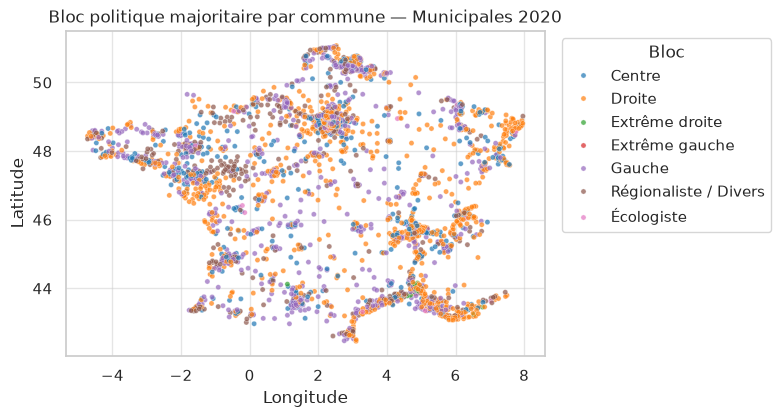

In [85]:
# Carte unique sur la dernière année disponible, en mettant en avant les 2 blocs
# majoritaires les plus fréquents pour une lecture plus simple
derniere_annee = max(annees)
sous = geo_plot[(geo_plot["Annee"] == derniere_annee) & (geo_plot["bloc_majoritaire"] != "Non Communiqué")]

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=sous, x="longitude", y="latitude", hue="bloc_majoritaire",
    hue_order=bloc_order, palette=palette, s=14, alpha=0.7, ax=ax,
)
ax.set_title(f"Bloc politique majoritaire par commune — Municipales {derniere_annee}")
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Bloc", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 5.2 Carte de l'abstention

Même logique appliquée au **taux d'abstention**, pour repérer une éventuelle structure
géographique du désengagement électoral, à rapprocher des cartes précédentes.


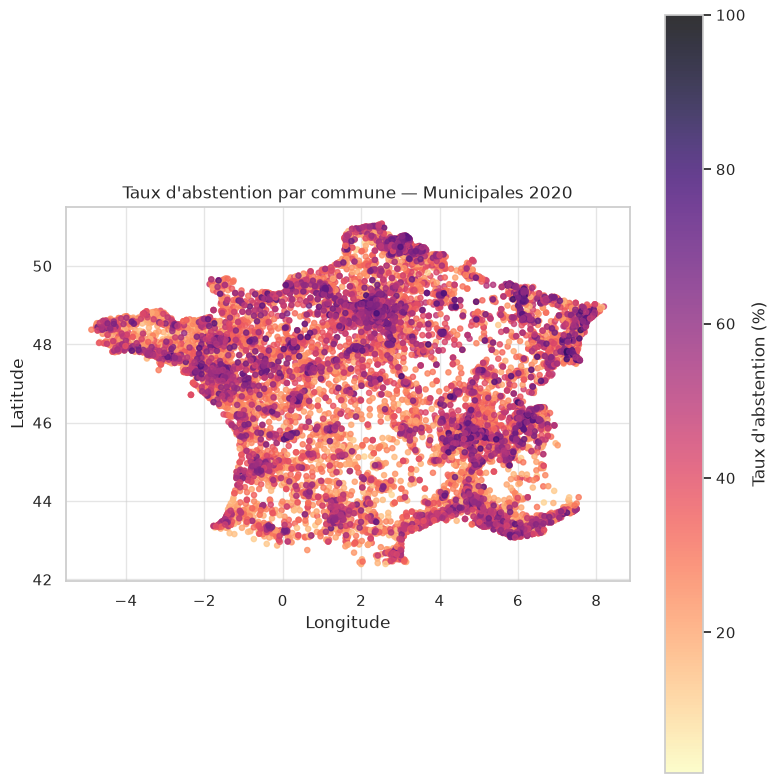

In [86]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    part_strate_bloc["longitude"], part_strate_bloc["latitude"],
    c=part_strate_bloc["taux_abstention"] * 100,
    cmap="magma_r", s=14, alpha=0.8,
)
fig.colorbar(sc, ax=ax, label="Taux d'abstention (%)")
ax.set_title(f"Taux d'abstention par commune — Municipales {derniere_annee}")
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


In [89]:
df

,Annee,Tour,Code département,Code commune,Libellé commune,Code BV,Inscrits,Votants,Abstentions,Exprimés,Code Nuance,Voix,Nuance,Libellé,code_insee,geo_nom,population,surface_km2,longitude,latitude,ID Bureau de vote,Vote Blanc,strate,bureau_anormal,taux_participation,taux_abstention,taux_vote_blanc_nul,nb_sieges_estime,pct_voix_exprimes_brut,pct_voix_exprimes_normalise,bloc_politique
0,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LUG,172.0,LUG,Liste Union de la Gauche,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.292020,0.292020,Gauche
1,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LGC,111.0,LGC,Liste gauche-centristes,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.188455,0.188455,Gauche
2,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LDVD,214.0,LDVD,Liste divers droite,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.363328,0.363328,Droite
3,2008,1,1,4,Ambérieu-en-Bugey,0001,1100,622,478,589,LDVD,92.0,LDVD,Liste divers droite,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1,33,>= 1000 hab,False,0.565455,0.434545,0.053055,1.0,0.156197,0.156197,Droite
4,2008,1,1,4,Ambérieu-en-Bugey,0002,935,497,438,477,LUG,148.0,LUG,Liste Union de la Gauche,1004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,2,20,>= 1000 hab,False,0.531551,0.468449,0.040241,1.0,0.310273,0.310273,Gauche
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1584246,2026,2,95,95680,Villiers-le-Bel,0013,946,508,438,505,LFI,260.0,LFI,La France insoumise,9595680,NaN,946.0,NaN,NaN,NaN,13,3,< 1000 hab,False,0.536998,0.463002,0.005906,NaN,0.514851,0.000000,Gauche
1584247,2026,2,95,95680,Villiers-le-Bel,0014,993,487,506,476,LSOC,258.0,LSOC,Liste du Parti socialiste,9595680,NaN,993.0,NaN,NaN,NaN,14,11,< 1000 hab,False,0.490433,0.509567,0.022587,NaN,0.542017,0.000000,Gauche
1584248,2026,2,95,95680,Villiers-le-Bel,0014,993,487,506,476,LFI,218.0,LFI,La France insoumise,9595680,NaN,993.0,NaN,NaN,NaN,14,11,< 1000 hab,False,0.490433,0.509567,0.022587,NaN,0.457983,0.000000,Gauche
1584249,2026,2,95,95680,Villiers-le-Bel,0015,1086,577,509,564,LSOC,359.0,LSOC,Liste du Parti socialiste,9595680,NaN,1086.0,NaN,NaN,NaN,15,13,>= 1000 hab,False,0.531308,0.468692,0.022530,1.0,0.636525,0.636525,Gauche


In [88]:
df.to_csv("../../data/processed/Analysis_Geo.csv", index=False)